#Phase 2 Return Analysis

#1. Imports


In [1]:
import sys 
from pathlib import Path
import pandas as pd 
import matplotlib.pyplot as plt 

project_root = Path.cwd().parent
sys.path.append(str(project_root))


#2. Load Processed Data

In [2]:
data_path = project_root / "data" / "processed" / "close_prices.csv"

close_prices = pd.read_csv(
    data_path,
    header =  0,
    index_col = 0,
    parse_dates = True
)

close_prices.head()

,GLD,TLT,SPY,JPM,XOM,AAPL,JNJ,KO
Date,,,,,,,,
2016-01-04,102.889999,90.649765,169.471558,48.184082,49.319611,23.709105,75.337540,30.555973
2016-01-05,103.180000,90.284058,169.758179,48.267384,49.739857,23.114973,75.652451,30.664066
2016-01-06,104.669998,91.500671,167.616837,47.570599,49.325985,22.662617,75.270050,30.498314
2016-01-07,106.150002,91.664886,163.595413,45.646862,48.536465,21.706154,74.392822,29.993847
2016-01-08,105.680000,92.075424,161.799667,44.624424,47.555916,21.820930,73.598061,29.914579


#3. Calculate Daily Returns

In [3]:
daily_returns = close_prices.pct_change()
daily_returns.head()

,GLD,TLT,SPY,JPM,XOM,AAPL,JNJ,KO
Date,,,,,,,,
2016-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-05,0.002819,-0.004034,0.001691,0.001729,0.008521,-0.025059,0.004180,0.003538
2016-01-06,0.014441,0.013475,-0.012614,-0.014436,-0.008321,-0.019570,-0.005055,-0.005405
2016-01-07,0.014140,0.001795,-0.023992,-0.040440,-0.016006,-0.042204,-0.011654,-0.016541
2016-01-08,-0.004428,0.004479,-0.010977,-0.022399,-0.020202,0.005288,-0.010683,-0.002643


In [4]:
daily_returns = daily_returns.dropna()
daily_returns.head()

,GLD,TLT,SPY,JPM,XOM,AAPL,JNJ,KO
Date,,,,,,,,
2016-01-05,0.002819,-0.004034,0.001691,0.001729,0.008521,-0.025059,0.004180,0.003538
2016-01-06,0.014441,0.013475,-0.012614,-0.014436,-0.008321,-0.019570,-0.005055,-0.005405
2016-01-07,0.014140,0.001795,-0.023992,-0.040440,-0.016006,-0.042204,-0.011654,-0.016541
2016-01-08,-0.004428,0.004479,-0.010977,-0.022399,-0.020202,0.005288,-0.010683,-0.002643
2016-01-11,-0.008895,-0.010944,0.000990,-0.001528,-0.013388,0.016192,-0.006010,0.001687


In [5]:
daily_returns.shape

(2651, 8)

In [6]:
daily_returns.isnull().sum()

GLD     0
TLT     0
SPY     0
JPM     0
XOM     0
AAPL    0
JNJ     0
KO      0
dtype: int64

In [7]:
daily_returns.describe() 

,GLD,TLT,SPY,JPM,XOM,AAPL,JNJ,KO
count,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000
mean,0.000545,0.000012,0.000623,0.000895,0.000586,0.001155,0.000529,0.000439
std,0.010233,0.009290,0.011218,0.017263,0.017608,0.018216,0.011643,0.011446
min,-0.102742,-0.066683,-0.109424,-0.149649,-0.122248,-0.128647,-0.100379,-0.096725
25%,-0.004636,-0.005547,-0.003581,-0.007020,-0.008189,-0.007109,-0.004778,-0.004768
50%,0.000669,0.000295,0.000731,0.000819,0.000583,0.001097,0.000466,0.000642
75%,0.005635,0.005379,0.005948,0.008979,0.009399,0.010023,0.006080,0.005968
max,0.063587,0.075196,0.105019,0.180125,0.126868,0.153289,0.079977,0.064796


#4. Explore Daily Returns

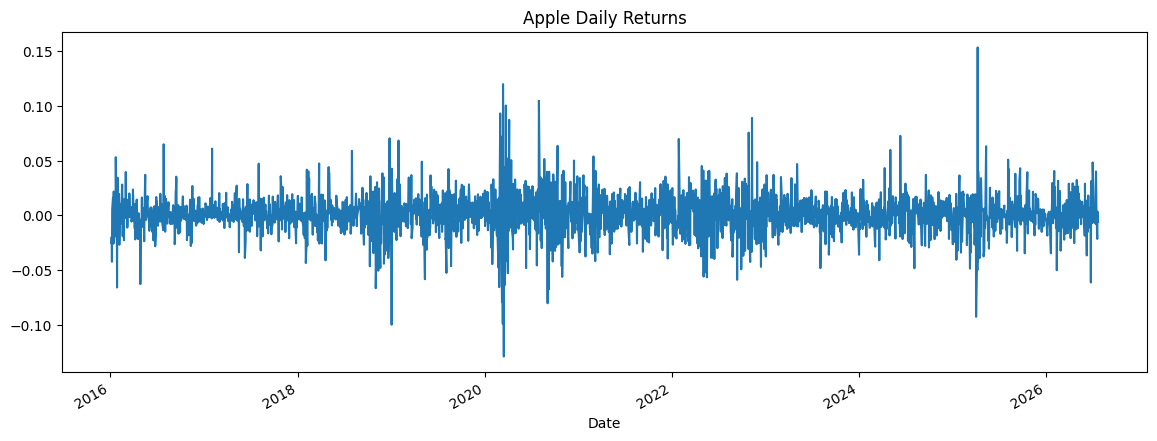

In [8]:
daily_returns["AAPL"].plot(figsize = (14,5), title = "Apple Daily Returns")
plt.show()

#5. Cumulative Returns

In [9]:
cumulative_returns = (1 + daily_returns).cumprod()

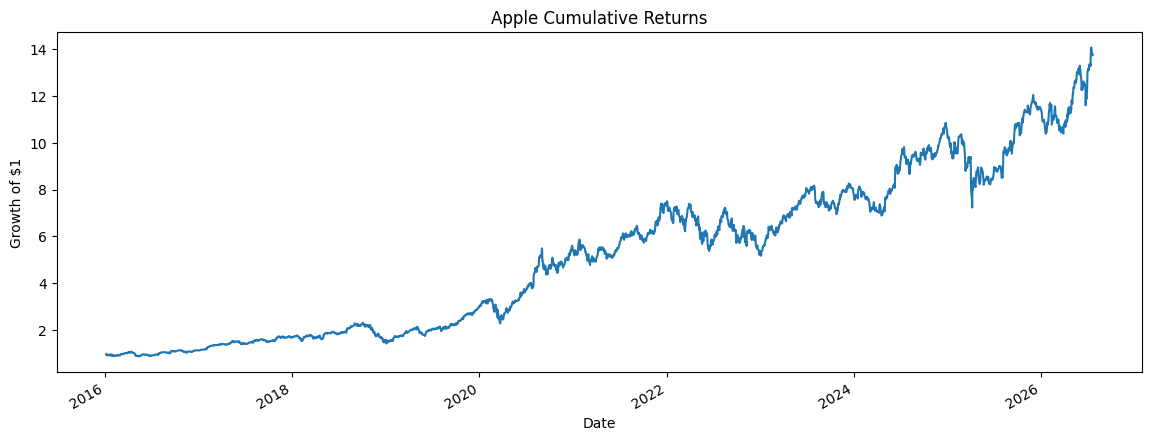

In [10]:
cumulative_returns["AAPL"].plot(figsize= (14,5), title= "Apple Cumulative Returns")
plt.ylabel("Growth of $1")
plt.show()

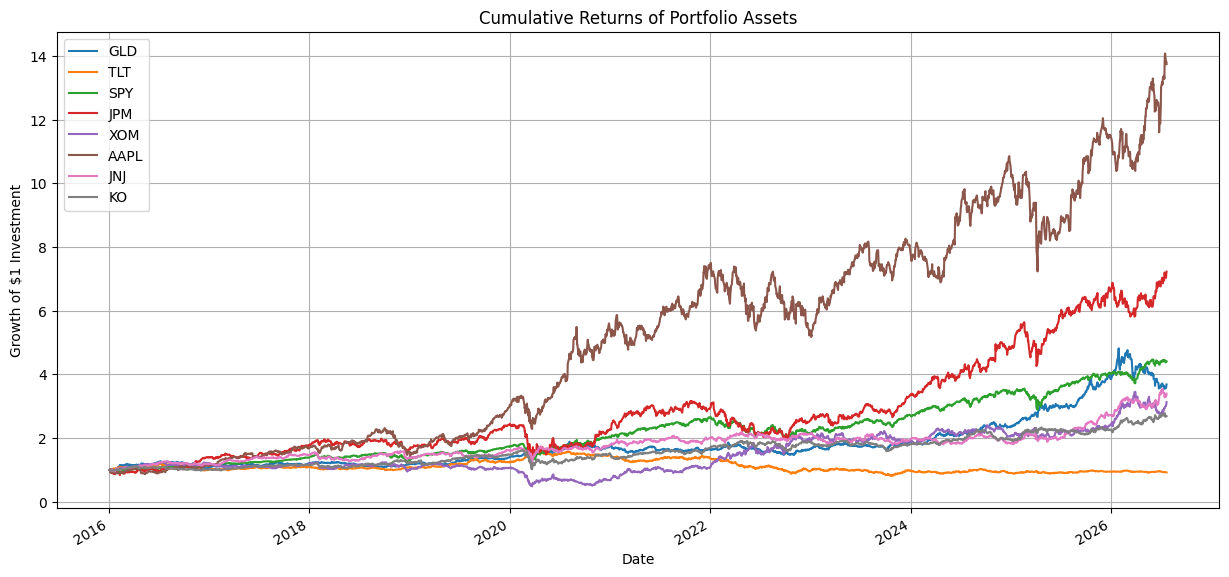

In [11]:
cumulative_returns.plot(figsize=(15,7))

plt.title("Cumulative Returns of Portfolio Assets")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Investment")

plt.grid(True)
plt.show()

In [12]:
total_returns = (cumulative_returns.iloc[-1] - 1) * 100

total_returns.sort_values(ascending=False)

AAPL    1274.535315
JPM      622.666027
SPY      341.023841
GLD      268.471180
JNJ      239.312919
XOM      213.161428
KO       169.014496
TLT       -7.953427
Name: 2026-07-22 00:00:00, dtype: float64

In [13]:
daily_returns.to_csv(
    project_root / "data" / "processed" / "daily_returns.csv"
)

print("Daily returns saved successfully!")

Daily returns saved successfully!


#Correlation Matrix

In [14]:
correlation_matrix= daily_returns.corr()
correlation_matrix

,GLD,TLT,SPY,JPM,XOM,AAPL,JNJ,KO
GLD,1.000000,0.259907,0.076342,-0.063801,0.036421,0.035133,0.043699,0.044607
TLT,0.259907,1.000000,-0.155990,-0.307057,-0.237250,-0.092116,-0.086755,-0.071796
SPY,0.076342,-0.155990,1.000000,0.701697,0.486361,0.741368,0.428062,0.491976
JPM,-0.063801,-0.307057,0.701697,1.000000,0.503279,0.407726,0.329744,0.385279
XOM,0.036421,-0.237250,0.486361,0.503279,1.000000,0.277226,0.283460,0.355109
AAPL,0.035133,-0.092116,0.741368,0.407726,0.277226,1.000000,0.289435,0.323400
JNJ,0.043699,-0.086755,0.428062,0.329744,0.283460,0.289435,1.000000,0.494959
KO,0.044607,-0.071796,0.491976,0.385279,0.355109,0.323400,0.494959,1.000000


#Histogram of Returns 

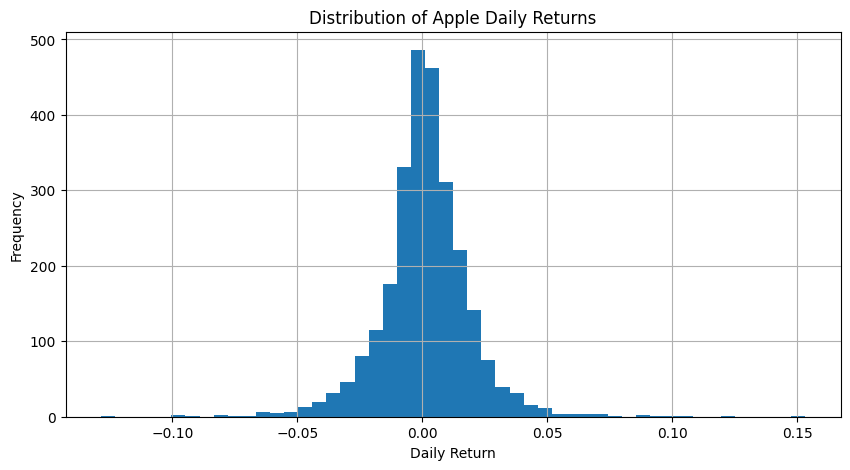

In [15]:
daily_returns["AAPL"].hist(
    bins=50,
    figsize=(10,5)
)

plt.title("Distribution of Apple Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()